In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q git+https://github.com/facebookresearch/detectron2.git
# !pip install -U detectron2


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 46.0 MB/s eta 0:00:00


# **Resnet/ detectornet**

In [3]:
import os
import json
import random
import shutil
from PIL import Image
from tqdm import tqdm

# === CONFIG ===
annotations_folder = '/kaggle/input/cottonweeddet3/CottonWeedDet3/annotations'
images_folder = '/kaggle/input/cottonweeddet3/CottonWeedDet3/images'
output_folder = '/kaggle/working/coco_dataset'
output_images_folder = os.path.join(output_folder, "images")

# Create output folders
os.makedirs(output_folder, exist_ok=True)
os.makedirs(os.path.join(output_images_folder, "train"), exist_ok=True)  # ✅ NEW
os.makedirs(os.path.join(output_images_folder, "val"), exist_ok=True)    # ✅ NEW

# Classes
class_map = {
    'carpetweed': 0,
    'morningglory': 1,
    'palmer_amaranth': 2
}
categories = [{"id": v, "name": k, "supercategory": "weed"} for k, v in class_map.items()]

# Step 1: Collect all image-label data
image_data = []

for json_file in os.listdir(annotations_folder):
    if not json_file.endswith('.json'):
        continue

    with open(os.path.join(annotations_folder, json_file)) as f:
        data = json.load(f)

    for item_key in data:
        item = data[item_key]
        filename = item['filename']
        regions = item['regions']
        image_path = os.path.join(images_folder, filename)

        if not os.path.exists(image_path):
            print(f"[⚠️ Skipping] Image not found: {filename}")
            continue

        try:
            with Image.open(image_path) as img:
                width, height = img.size
        except Exception as e:
            print(f"[❌ Error opening] {filename}: {e}")
            continue

        bboxes = []
        for region in regions:
            shape_attr = region['shape_attributes']
            region_attr = region['region_attributes']

            if shape_attr['name'] != 'rect':
                continue

            x = shape_attr['x']
            y = shape_attr['y']
            w = shape_attr['width']
            h = shape_attr['height']
            class_name = region_attr['class'].lower()

            if class_name not in class_map:
                continue

            bbox = {
                "category_id": class_map[class_name],
                "bbox": [x, y, w, h],
                "area": w * h
            }
            bboxes.append(bbox)

        if bboxes:
            image_data.append({
                "file_name": filename,
                "width": width,
                "height": height,
                "bboxes": bboxes
            })

# Step 2: Split into train and val
from sklearn.model_selection import train_test_split

# Extract a label for stratification (just first class per image for simplicity)
image_labels = []
for img in image_data:
    # You can also consider set of all class_ids in image if needed
    first_class_id = img['bboxes'][0]['category_id']
    image_labels.append(first_class_id)

# Stratified split
train_imgs, val_imgs = train_test_split(
    image_data, 
    test_size=0.2, 
    random_state=42, 
    stratify=image_labels
)

splits = {
    "train": train_imgs,
    "val": val_imgs
}

# Step 3: Write COCO-style JSONs and copy images
def create_coco_json(data_split, split_name):
    coco = {
        "images": [],
        "annotations": [],
        "categories": categories
    }

    ann_id = 1
    for img_id, item in enumerate(tqdm(data_split), start=1):
        new_img_path = os.path.join(output_images_folder, split_name, item["file_name"])
        old_img_path = os.path.join(images_folder, item["file_name"])

        # ✅ Copy image to appropriate split folder
        shutil.copyfile(old_img_path, new_img_path)

        coco["images"].append({
            "id": img_id,
            "file_name": f"{split_name}/{item['file_name']}",
            "width": item["width"],
            "height": item["height"]
        })

        for bbox in item["bboxes"]:
            coco["annotations"].append({
                "id": ann_id,
                "image_id": img_id,
                "category_id": bbox["category_id"],
                "bbox": bbox["bbox"],
                "area": bbox["area"],
                "iscrowd": 0
            })
            ann_id += 1

    # Save annotations
    json_path = os.path.join(output_folder, f"annotations_{split_name}.json")
    with open(json_path, 'w') as f:
        json.dump(coco, f, indent=4)
    print(f"✅ COCO annotations saved to: {json_path}")

# Generate both splits
create_coco_json(splits["train"], "train")
create_coco_json(splits["val"], "val")


100%|██████████| 678/678 [00:40<00:00, 16.62it/s]


✅ COCO annotations saved to: /kaggle/working/coco_dataset/annotations_train.json


100%|██████████| 170/170 [00:10<00:00, 15.72it/s]


✅ COCO annotations saved to: /kaggle/working/coco_dataset/annotations_val.json


In [4]:
import json
from collections import defaultdict

# Path to your COCO annotation file
json_path = "/kaggle/working/coco_dataset/annotations_train.json"  # or val/test if needed

# Load the JSON
with open(json_path, 'r') as f:
    data = json.load(f)

# Create a mapping from category_id to category_name
category_id_to_name = {cat['id']: cat['name'] for cat in data['categories']}

# Count the number of annotations per class
class_counts = defaultdict(int)

for ann in data['annotations']:
    class_id = ann['category_id']
    class_counts[class_id] += 1

# Print results
print("Class distribution in dataset:")
for class_id, count in class_counts.items():
    print(f"{category_id_to_name[class_id]}: {count} instances")


Class distribution in dataset:
morningglory: 397 instances
carpetweed: 464 instances
palmer_amaranth: 359 instances


In [5]:
from collections import Counter

def count_classes(images):
    counter = Counter()
    for img in images:
        for bbox in img['bboxes']:
            counter[bbox['category_id']] += 1
    return counter

print("Train class distribution:", count_classes(splits["train"]))
print("Val class distribution:", count_classes(splits["val"]))


Train class distribution: Counter({0: 464, 1: 397, 2: 359})
Val class distribution: Counter({0: 138, 1: 89, 2: 85})


In [6]:
from detectron2.data import DatasetCatalog, MetadataCatalog

# Function to safely remove a dataset + its metadata
def unregister_dataset(name):
    if name in DatasetCatalog.list():
        DatasetCatalog.remove(name)
    if name in MetadataCatalog.list():
        MetadataCatalog.remove(name)

# Unregister if already exists
unregister_dataset("cottonweed_train")
unregister_dataset("cottonweed_val")

# Register again with the correct JSON and image paths
from detectron2.data.datasets import register_coco_instances

register_coco_instances(
    "cottonweed_train",
    {},
    "/kaggle/working/coco_dataset/annotations_train.json",
    "/kaggle/working/coco_dataset/images/"
)

register_coco_instances(
    "cottonweed_val",
    {},
    "/kaggle/working/coco_dataset/annotations_val.json",
    "/kaggle/working/coco_dataset/images/"
    
)
# Confirm registration
if "cottonweed_train" in DatasetCatalog.list() and "cottonweed_val" in DatasetCatalog.list():
    print("Success ✅")
else:
    print("Failed")

# Check if registration was successful
print("Registered Datasets:")
print(DatasetCatalog.list())

# Optional: Print sample from each dataset
for name in ["cottonweed_train", "cottonweed_val"]:
    print(f"\n{name} Metadata:")
    metadata = MetadataCatalog.get(name)
    print(metadata)

    dataset_dicts = DatasetCatalog.get(name)
    print(f"Sample from {name}:")
    if dataset_dicts:
        print(dataset_dicts[0])
    else:
        print("No data found in this dataset.")



Success ✅
Registered Datasets:
['coco_2014_train', 'coco_2014_val', 'coco_2014_minival', 'coco_2014_valminusminival', 'coco_2017_train', 'coco_2017_val', 'coco_2017_test', 'coco_2017_test-dev', 'coco_2017_val_100', 'keypoints_coco_2014_train', 'keypoints_coco_2014_val', 'keypoints_coco_2014_minival', 'keypoints_coco_2014_valminusminival', 'keypoints_coco_2017_train', 'keypoints_coco_2017_val', 'keypoints_coco_2017_val_100', 'coco_2017_train_panoptic_separated', 'coco_2017_train_panoptic_stuffonly', 'coco_2017_train_panoptic', 'coco_2017_val_panoptic_separated', 'coco_2017_val_panoptic_stuffonly', 'coco_2017_val_panoptic', 'coco_2017_val_100_panoptic_separated', 'coco_2017_val_100_panoptic_stuffonly', 'coco_2017_val_100_panoptic', 'lvis_v1_train', 'lvis_v1_val', 'lvis_v1_test_dev', 'lvis_v1_test_challenge', 'lvis_v0.5_train', 'lvis_v0.5_val', 'lvis_v0.5_val_rand_100', 'lvis_v0.5_test', 'lvis_v0.5_train_cocofied', 'lvis_v0.5_val_cocofied', 'cityscapes_fine_instance_seg_train', 'cityscape

In [7]:
import torch
torch.cuda.empty_cache()


In [8]:
import os
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultTrainer
import logging
from detectron2.utils.logger import setup_logger
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
import warnings
warnings.filterwarnings("ignore")

# setup_logger()

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/retinanet_R_101_FPN_3x.yaml"))

# Dataset names registered earlier
cfg.DATASETS.TRAIN = ("cottonweed_train",)
cfg.DATASETS.TEST = ("cottonweed_val",)

cfg.DATALOADER.NUM_WORKERS = 2

# Use pretrained RetinaNet weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/retinanet_R_101_FPN_3x.yaml") 

# Training hyperparameters
cfg.SOLVER.IMS_PER_BATCH = 4
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 1500
cfg.SOLVER.STEPS = [] 
cfg.SOLVER.CHECKPOINT_PERIOD = 200

cfg.TEST.EVAL_PERIOD = 100
# Update number of classes (3 weed types)
cfg.MODEL.RETINANET.NUM_CLASSES = 3
cfg.SOLVER.AMP.ENABLED = True

# Save output inside working dir
cfg.OUTPUT_DIR = "/kaggle/working/output_cottonweed"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Start training
trainer = DefaultTrainer(cfg) 
trainer.resume_or_load(resume=False)
trainer.train()


# Load best model after trainingc
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # or model_best.pth if using EvalHook

evaluator = COCOEvaluator("cottonweed_val", cfg, False, output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "cottonweed_val")

# Evaluate and print metrics
metrics = inference_on_dataset(trainer.model, val_loader, evaluator)
print(metrics)

model_final_971ab9.pkl: 228MB [00:01, 186MB/s]                           


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.618
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.791
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.676
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.620
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.492
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.756
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.790
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:

In [9]:
# # May work in local or colab, not Kaggle
# %load_ext tensorboard
# %tensorboard --logdir /kaggle/working/output_cottonweed


In [10]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("cottonweed_val", cfg, False, output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "cottonweed_val")
inference_on_dataset(trainer.model, val_loader, evaluator)


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.618
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.791
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.676
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.620
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.492
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.756
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.790
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:

OrderedDict([('bbox',
              {'AP': 61.84988590117017,
               'AP50': 79.07915985265025,
               'AP75': 67.60660892438717,
               'APs': nan,
               'APm': 0.0,
               'APl': 61.97973208834776,
               'AP-carpetweed': 53.355557557226106,
               'AP-morningglory': 71.99503136553143,
               'AP-palmer_amaranth': 60.19906878075298})])

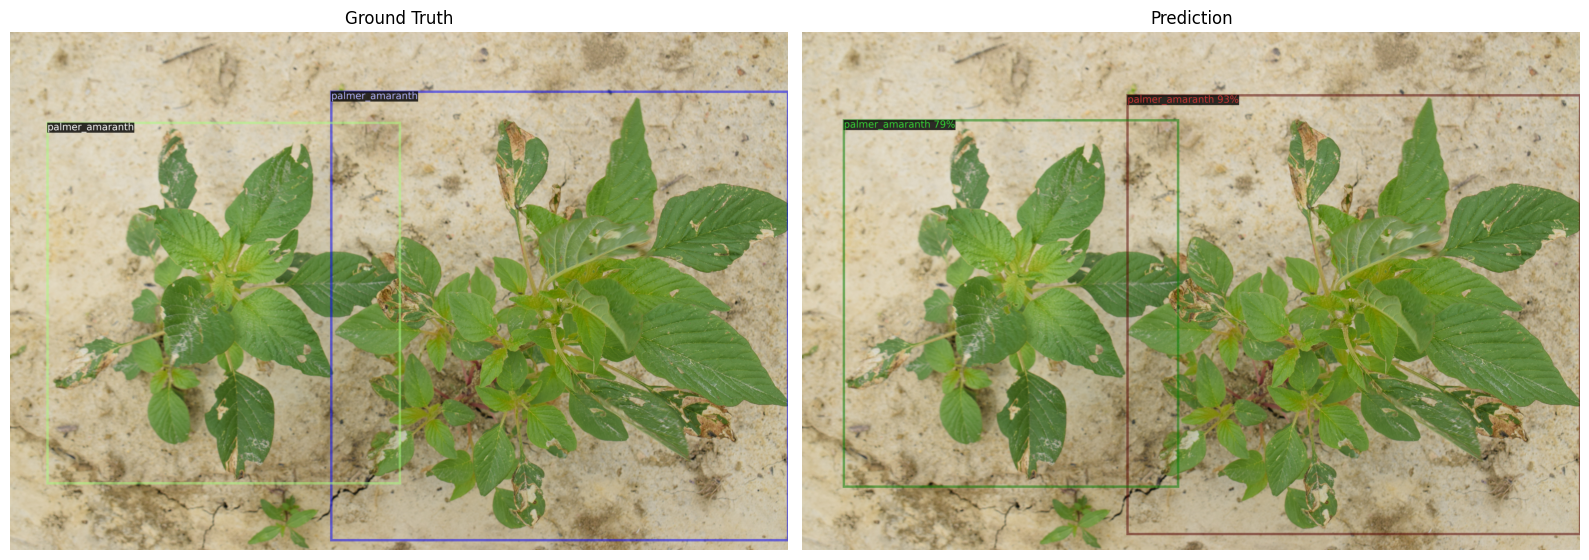

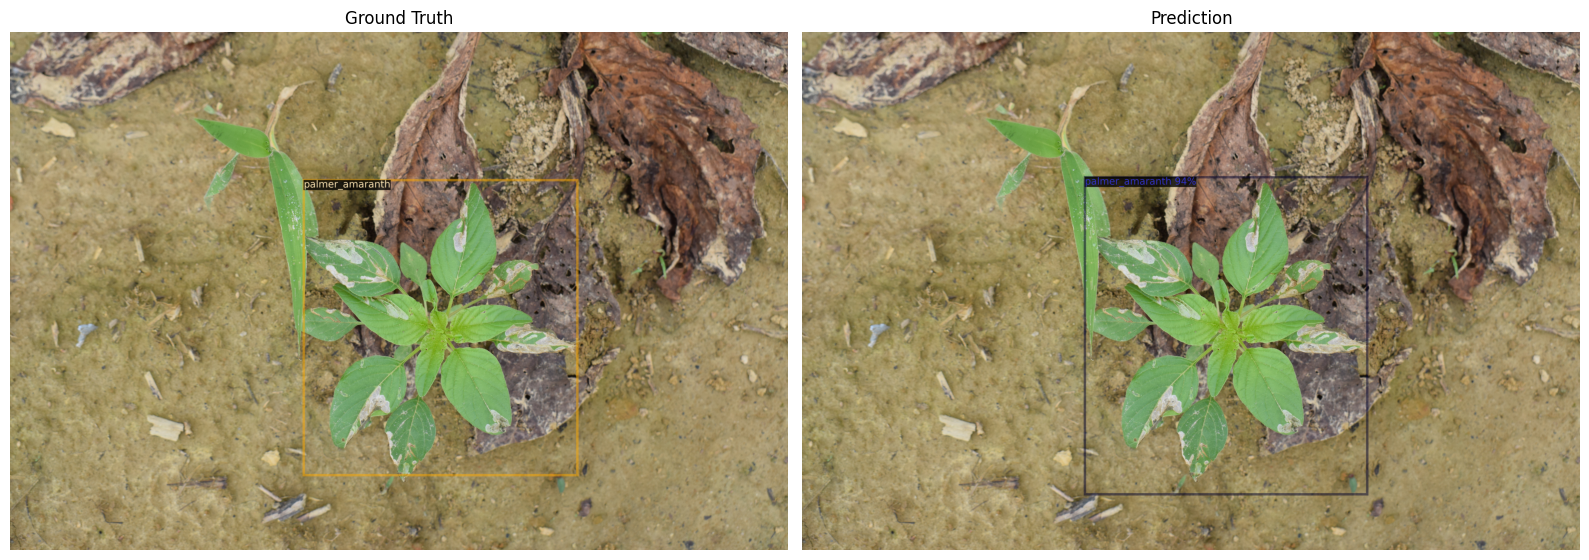

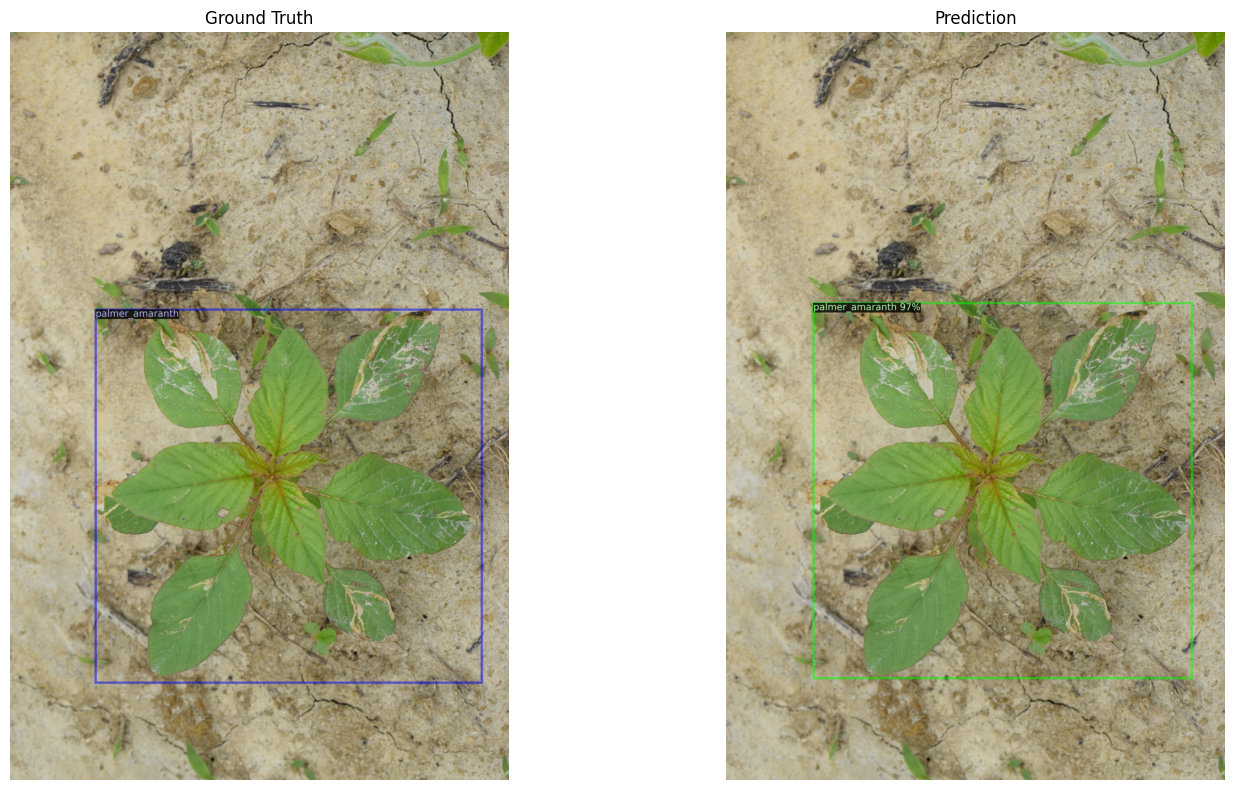

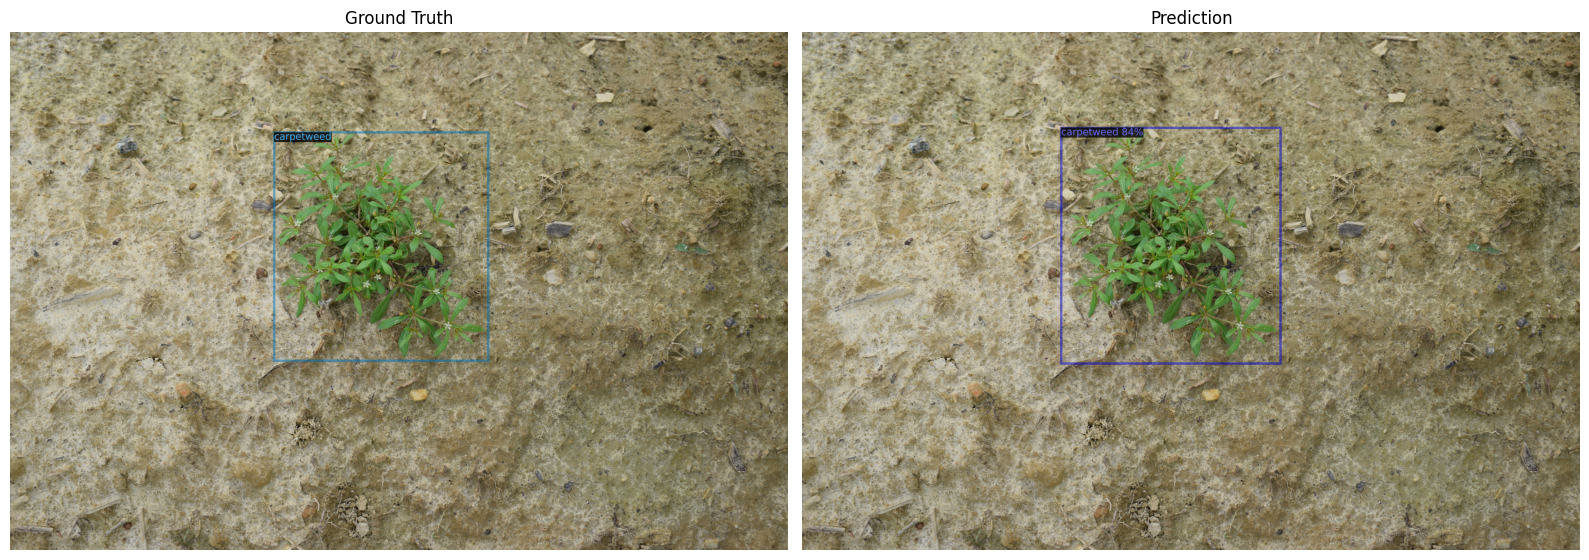

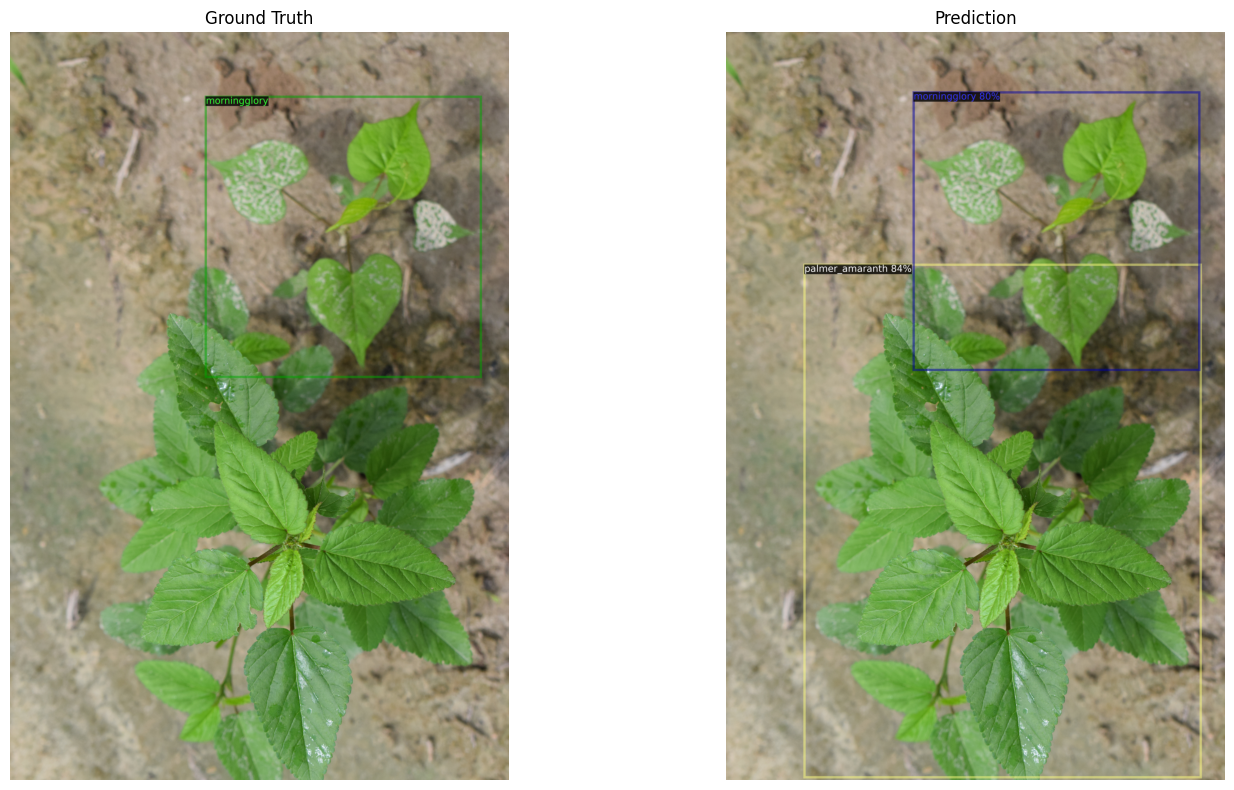

In [11]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.engine import DefaultPredictor
from detectron2.data.datasets import register_coco_instances

# === Register COCO dataset ===
dataset_name = "cottonweed_val"
val_json = "/kaggle/working/coco_dataset/annotations_val.json"
val_img_dir = "/kaggle/working/coco_dataset/images/"
register_coco_instances(dataset_name, {}, val_json, val_img_dir)

# === Load model & config ===
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.DATASETS.TEST = (dataset_name,)
cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = 0.8
cfg.MODEL.RETINANET.SCORE_THRESH_TEST = 0.5
predictor = DefaultPredictor(cfg)

# === Metadata & dataset ===
metadata = MetadataCatalog.get(dataset_name)
dataset_dicts = DatasetCatalog.get(dataset_name)

# === Compare 5 random images ===
for d in random.sample(dataset_dicts, 5):
    file_path = d["file_name"]
    im = cv2.imread(file_path)

    # === Prediction ===
    outputs = predictor(im)
    v_pred = Visualizer(im[:, :, ::-1], metadata=metadata, scale=0.8)
    pred_vis = v_pred.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()

    # === Ground Truth ===
    v_gt = Visualizer(im[:, :, ::-1], metadata=metadata, scale=0.8)
    gt_vis = v_gt.draw_dataset_dict(d).get_image()

    # === Show side-by-side ===
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    axs[0].imshow(gt_vis)
    axs[0].set_title("Ground Truth")
    axs[0].axis("off")

    axs[1].imshow(pred_vis)
    axs[1].set_title("Prediction")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()


# rcnn

In [12]:
import os
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo

# Config setup
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_X_101_32x8d_FPN_3x.yaml"))

# Dataset names (make sure you have already registered them)
cfg.DATASETS.TRAIN = ("cottonweed_train",)
cfg.DATASETS.TEST = ("cottonweed_val",)

cfg.DATALOADER.NUM_WORKERS = 2

# Use pretrained weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_X_101_32x8d_FPN_3x.yaml")

# Training hyperparameters
cfg.SOLVER.IMS_PER_BATCH = 4
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 1500        # Adjust based on dataset size
cfg.SOLVER.STEPS = []             # No LR decay
cfg.SOLVER.CHECKPOINT_PERIOD = 200

# Number of classes
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3  # carpetweed, morningglory, palmer_amaranth

# Score threshold at test time (used for inference and evaluation)
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.25

# AMP (Automatic Mixed Precision)
cfg.SOLVER.AMP.ENABLED = True

# Output directory
cfg.OUTPUT_DIR = "/kaggle/working/output_frcnn_x101"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Save config to output folder
with open(os.path.join(cfg.OUTPUT_DIR, "config.yaml"), "w") as f:
    f.write(cfg.dump())

# Start training
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

# Load best model after training
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final2.pth")  # or model_best.pth if using EvalHook

evaluator = COCOEvaluator("cottonweed_val", cfg, False, output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "cottonweed_val")

# Evaluate and print metrics
metrics = inference_on_dataset(trainer.model, val_loader, evaluator)
print(metrics)

model_final_68b088.pkl: 421MB [00:01, 211MB/s]                           


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.498
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.722
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.539
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.499
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.449
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.632
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.636
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50: